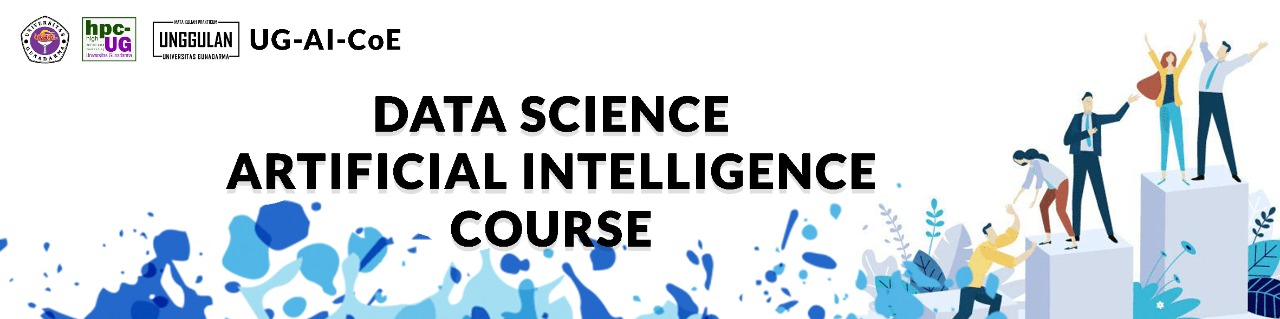

# Tugas Mandiri Pertemuan 4
## Segmentasi Perilaku Sesi Pengunjung E-Commerce Menggunakan K-Means

Nama: Fachri Aziz  
NPM: 50423421  
Kelas: E

## 1. Business Understanding

Dataset Online Shoppers Purchasing Intention berisi aktivitas pengunjung selama menggunakan website e-commerce. Setiap baris merepresentasikan satu sesi dan mencatat jumlah halaman yang dikunjungi, durasi kunjungan, bounce rate, exit rate, serta informasi apakah sesi tersebut menghasilkan transaksi.

Permasalahan yang ingin diselesaikan adalah menemukan kelompok sesi dengan pola perilaku yang serupa. Hasil clustering dapat membantu pengelola website memahami sesi dengan engagement tinggi, sesi yang hanya melakukan penjelajahan singkat, dan sesi yang langsung meninggalkan website.

Tujuan analisis ini adalah melakukan segmentasi sesi pengunjung menggunakan K-Means, menentukan jumlah cluster berdasarkan Elbow Method, Silhouette Score, dan Davies-Bouldin Index, serta memberikan interpretasi dan rekomendasi untuk setiap cluster. Kolom Revenue tidak digunakan untuk membentuk cluster dan hanya digunakan setelah modeling untuk membantu membaca karakteristik bisnis setiap kelompok.

Sumber dataset: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## 2. Data Understanding

Tahap ini digunakan untuk memahami ukuran data, tipe data, statistik deskriptif, missing values, duplicate rows, dan distribusi fitur sebelum modeling dilakukan.

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")

print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
df.head()

Jumlah baris: 12330
Jumlah kolom: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315,3.322,0.0,0.000,1.000,4.000,27.000
Administrative_Duration,12330.0,80.819,176.779,0.0,0.000,7.500,93.256,3398.750
Informational,12330.0,0.504,1.270,0.0,0.000,0.000,0.000,24.000
Informational_Duration,12330.0,34.472,140.749,0.0,0.000,0.000,0.000,2549.375
ProductRelated,12330.0,31.731,44.476,0.0,7.000,18.000,38.000,705.000
ProductRelated_Duration,12330.0,1194.746,1913.669,0.0,184.138,598.937,1464.157,63973.522
BounceRates,12330.0,0.022,0.048,0.0,0.000,0.003,0.017,0.200
ExitRates,12330.0,0.043,0.049,0.0,0.014,0.025,0.050,0.200
PageValues,12330.0,5.889,18.568,0.0,0.000,0.000,0.000,361.764
SpecialDay,12330.0,0.061,0.199,0.0,0.000,0.000,0.000,1.000


In [5]:
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Jumlah baris identik setelah kemunculan pertama: {df.duplicated().sum()}")

Total missing values: 0
Jumlah baris identik setelah kemunculan pertama: 125


Dataset terdiri dari 12.330 baris dan 18 kolom tanpa missing values. Pemeriksaan menemukan 125 baris yang nilainya identik dengan baris sebelumnya. Baris tersebut tetap dipertahankan karena dokumentasi UCI menjelaskan bahwa setiap baris merepresentasikan sesi dari pengguna yang berbeda, sehingga kesamaan nilai tidak cukup menjadi bukti bahwa observasi tersebut merupakan kesalahan pencatatan. Seluruh fitur yang dipilih untuk clustering sudah bertipe numerik.

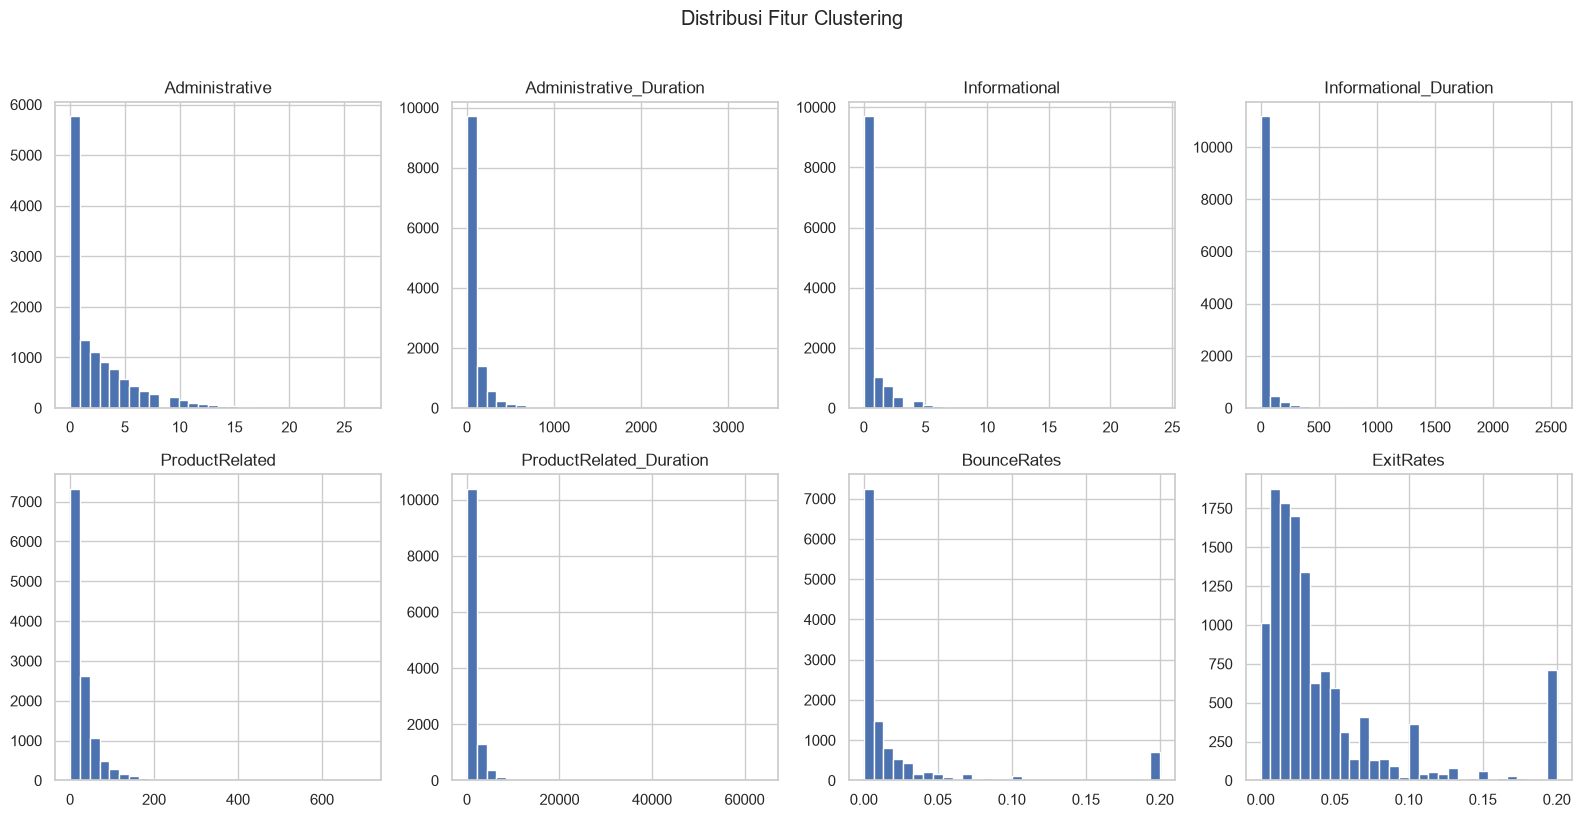

In [6]:
features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
]

df[features].hist(figsize=(16, 8), bins=30, layout=(2, 4))
plt.suptitle("Distribusi Fitur Clustering", y=1.02)
plt.tight_layout()
plt.show()

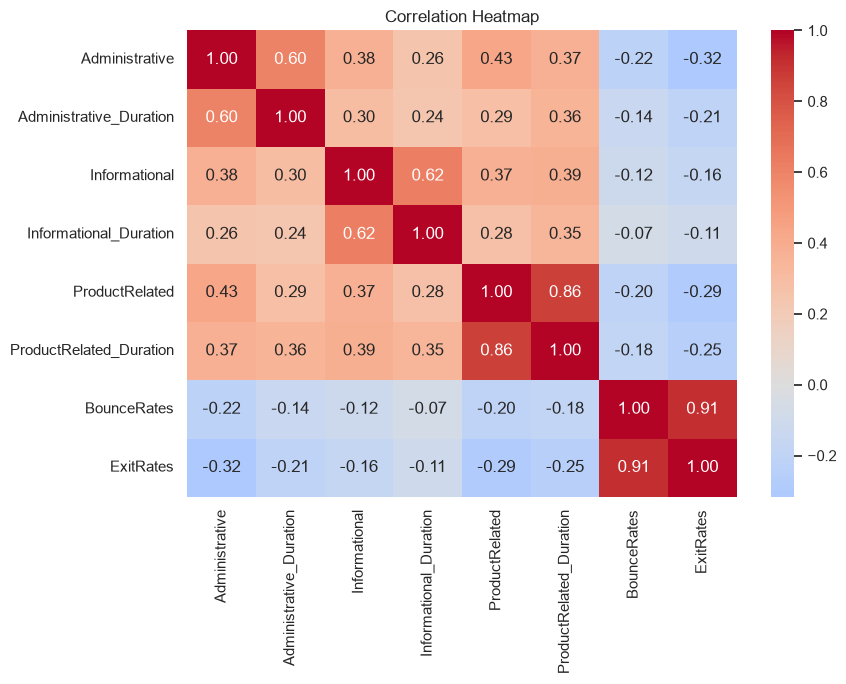

In [7]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [8]:
print("Distribusi Revenue:")
display(df["Revenue"].value_counts().to_frame("Jumlah"))

print("Distribusi VisitorType:")
display(df["VisitorType"].value_counts().to_frame("Jumlah"))

Distribusi Revenue:


,Jumlah
Revenue,
False,10422
True,1908


Distribusi VisitorType:


,Jumlah
VisitorType,
Returning_Visitor,10551
New_Visitor,1694
Other,85


Distribusi beberapa fitur terlihat right-skewed. Sebagai contoh, median ProductRelated adalah 18 halaman, sedangkan nilai maksimumnya mencapai 705 halaman. Median ProductRelated_Duration adalah sekitar 598,94 detik dengan nilai maksimum 63.973,52 detik. Perbedaan tersebut menunjukkan adanya sejumlah sesi dengan aktivitas yang jauh lebih tinggi daripada mayoritas sesi lainnya.

Correlation heatmap menunjukkan hubungan yang kuat antara BounceRates dan ExitRates, serta antara jumlah halaman dan durasi kunjungan pada kelompok halaman yang sama. Dataset juga didominasi oleh sesi yang tidak menghasilkan transaksi, yaitu 10.422 sesi, sedangkan 1.908 sesi menghasilkan transaksi. Returning_Visitor merupakan VisitorType terbanyak dengan 10.551 sesi.

## 3. Data Preparation

Baris dengan nilai identik tetap dipertahankan karena dokumentasi dataset menyatakan bahwa setiap baris merepresentasikan sesi yang berbeda. Delapan fitur numerik dipilih untuk menggambarkan aktivitas sesi. Revenue, PageValues, dan fitur kategorikal tidak digunakan dalam modeling.

In [9]:
df_model = df.copy()
X = df_model[features].copy()

log_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
]

X[log_features] = np.log1p(X[log_features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Jumlah data yang digunakan untuk modeling: {len(df_model)}")
print(f"Bentuk data setelah scaling: {X_scaled.shape}")

Jumlah data yang digunakan untuk modeling: 12330
Bentuk data setelah scaling: (12330, 8)


Seluruh 12.330 sesi digunakan dalam modeling dengan delapan fitur. Transformasi log1p diterapkan pada fitur jumlah halaman dan durasi karena distribusinya right-skewed. StandardScaler kemudian digunakan agar seluruh fitur memiliki skala yang sebanding sebelum perhitungan jarak pada K-Means.

## 4. Modeling

K-Means diuji menggunakan jumlah cluster dari 2 sampai 7. Inertia digunakan pada Elbow Method, Silhouette Score mengukur kualitas pemisahan cluster, sedangkan Davies-Bouldin Index mengukur kemiripan antar-cluster. Silhouette Score yang lebih tinggi dan Davies-Bouldin Index yang lebih rendah menunjukkan hasil yang lebih baik.

In [10]:
results = []

for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    results.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette Score": silhouette_score(X_scaled, labels),
        "Davies-Bouldin Index": davies_bouldin_score(X_scaled, labels),
    })

evaluation_df = pd.DataFrame(results).set_index("k")
evaluation_df.round(4)

,Inertia,Silhouette Score,Davies-Bouldin Index
k,,,
2,66709.3398,0.3250,1.2842
3,42808.0495,0.4469,0.8424
4,27942.2368,0.4240,0.8162
5,23775.0482,0.3792,0.8989
6,21076.5926,0.3741,1.0297
7,18550.8790,0.3399,1.1122


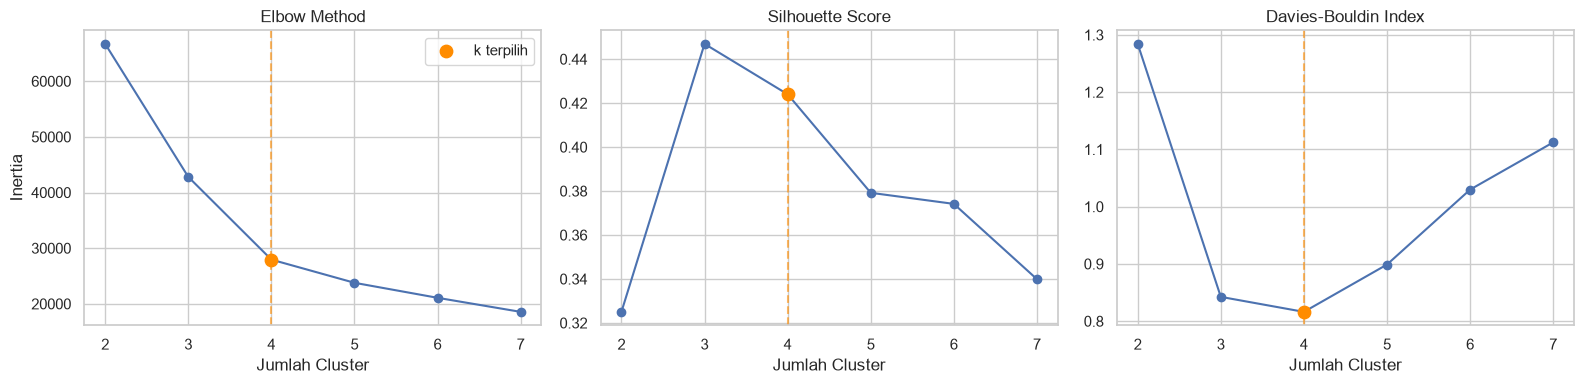

In [11]:
selected_k = 4
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics = [
    ("Inertia", "Elbow Method"),
    ("Silhouette Score", "Silhouette Score"),
    ("Davies-Bouldin Index", "Davies-Bouldin Index"),
]

for ax, (metric, title) in zip(axes, metrics):
    ax.plot(evaluation_df.index, evaluation_df[metric], marker="o")
    ax.scatter(
        selected_k,
        evaluation_df.loc[selected_k, metric],
        color="darkorange",
        s=80,
        zorder=3,
        label="k terpilih",
    )
    ax.axvline(selected_k, color="darkorange", linestyle="--", alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("Jumlah Cluster")
    ax.set_xticks(evaluation_df.index)

axes[0].set_ylabel("Inertia")
axes[0].legend()

plt.tight_layout()
plt.show()

Silhouette Score tertinggi diperoleh pada k=3 dengan nilai 0,4469. Namun, k=4 menghasilkan Davies-Bouldin Index terendah, yaitu 0,8162, dan penurunan inertia mulai melandai setelah empat cluster. Hasil cluster profiling juga menunjukkan bahwa k=4 memberikan empat pola perilaku yang lebih terperinci dan dapat diterjemahkan menjadi rekomendasi bisnis. Dengan mempertimbangkan kualitas cluster dan interpretasi bisnis, jumlah cluster yang dipilih adalah empat.

In [12]:
kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init=10)
df_model["Cluster"] = kmeans.fit_predict(X_scaled)

df_model["Cluster"].value_counts().sort_index().to_frame("Jumlah Sesi")

,Jumlah Sesi
Cluster,
0,4208
1,878
2,2214
3,5030


## 5. Evaluation

Cluster profiling dilakukan menggunakan median fitur asli agar karakteristik setiap kelompok tetap mudah dibaca. Revenue rate digunakan sebagai informasi tambahan setelah cluster terbentuk dan tidak memengaruhi proses modeling.

In [13]:
cluster_names = {
    0: "Product-Focused Explorers",
    1: "Immediate Bouncers",
    2: "Deeply Engaged Researchers",
    3: "Brief Returning Browsers",
}

cluster_profile = df_model.groupby("Cluster").agg(
    Jumlah_Sesi=("Cluster", "size"),
    Administrative=("Administrative", "median"),
    Informational=("Informational", "median"),
    ProductRelated=("ProductRelated", "median"),
    ProductRelated_Duration=("ProductRelated_Duration", "median"),
    BounceRates=("BounceRates", "median"),
    ExitRates=("ExitRates", "median"),
    Revenue_Rate=("Revenue", "mean"),
    Returning_Visitor_Rate=("VisitorType", lambda x: (x == "Returning_Visitor").mean()),
)

cluster_profile.insert(
    0,
    "Nama_Segmen",
    [cluster_names[cluster] for cluster in cluster_profile.index],
)
cluster_profile.insert(
    2,
    "Persentase_Sesi",
    cluster_profile["Jumlah_Sesi"] / len(df_model) * 100,
)

cluster_profile.round(4)

,Nama_Segmen,Jumlah_Sesi,Persentase_Sesi,Administrative,Informational,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,Revenue_Rate,Returning_Visitor_Rate
Cluster,,,,,,,,,,,
0,Product-Focused Explorers,4208,34.1281,3.0,0.0,24.0,800.4185,0.0000,0.0182,0.2013,0.7754
1,Immediate Bouncers,878,7.1208,0.0,0.0,1.0,0.0000,0.2000,0.2000,0.0046,0.9465
2,Deeply Engaged Researchers,2214,17.9562,4.0,2.0,43.0,1677.2152,0.0041,0.0187,0.2385,0.8925
3,Brief Returning Browsers,5030,40.7948,0.0,0.0,12.0,360.7500,0.0000,0.0360,0.1052,0.8909


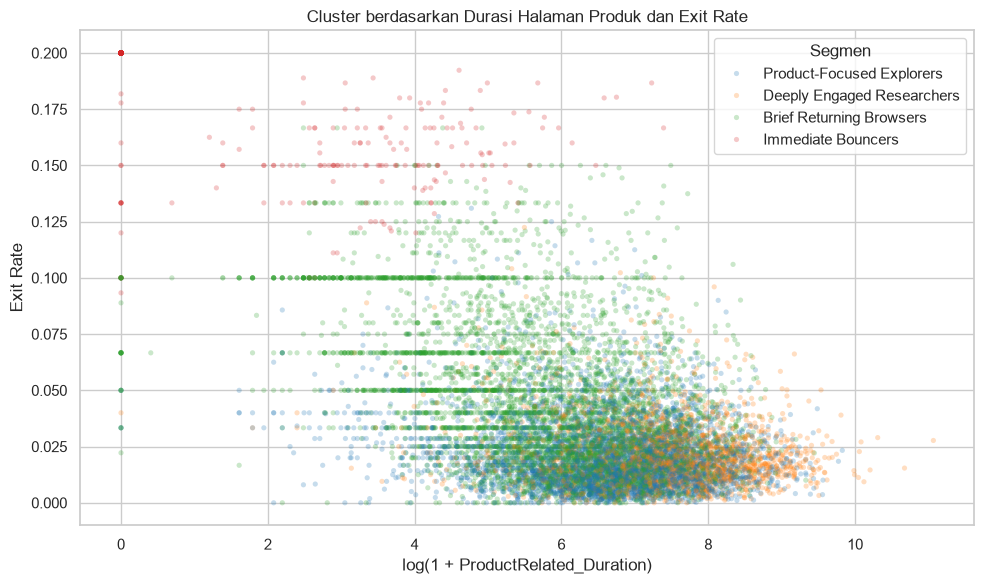

In [14]:
plot_df = df_model.assign(
    Cluster_Name=df_model["Cluster"].map(cluster_names),
    Log_ProductRelated_Duration=np.log1p(df_model["ProductRelated_Duration"]),
)

hue_order = [
    "Product-Focused Explorers",
    "Deeply Engaged Researchers",
    "Brief Returning Browsers",
    "Immediate Bouncers",
]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="Log_ProductRelated_Duration",
    y="ExitRates",
    hue="Cluster_Name",
    hue_order=hue_order,
    palette="tab10",
    alpha=0.25,
    s=14,
    linewidth=0,
)
plt.title("Cluster berdasarkan Durasi Halaman Produk dan Exit Rate")
plt.xlabel("log(1 + ProductRelated_Duration)")
plt.ylabel("Exit Rate")
plt.legend(title="Segmen", loc="upper right")
plt.tight_layout()
plt.show()

Cluster 0, Product-Focused Explorers, berisi 4.208 sesi atau 34,13% dari data. Median kunjungannya mencapai 24 halaman produk dengan durasi sekitar 800,42 detik dan exit rate 0,0182. Revenue rate kelompok ini sebesar 20,13%. Rekomendasi produk dan alur menuju checkout dapat diuji untuk membantu sesi yang sudah aktif menjelajahi produk.

Cluster 1, Immediate Bouncers, berisi 878 sesi atau 7,12% dari data. Median sesi hanya membuka satu halaman produk dengan durasi nol detik, sedangkan bounce rate dan exit rate sama-sama mencapai 0,20. Revenue rate-nya hanya 0,46%. Perbaikan relevansi landing page, kecepatan website, dan kualitas sumber traffic menjadi hipotesis yang layak diuji pada kelompok ini.

Cluster 2, Deeply Engaged Researchers, berisi 2.214 sesi atau 17,96% dari data dan menunjukkan engagement paling tinggi. Median sesi mengunjungi 4 halaman administratif, 2 halaman informasional, dan 43 halaman produk dengan durasi halaman produk sekitar 1.677,22 detik. Revenue rate kelompok ini merupakan yang tertinggi, yaitu 23,85%. Informasi produk yang lengkap, perbandingan produk, ulasan, dan call to action yang jelas dapat diuji untuk mendukung proses keputusan mereka.

Cluster 3, Brief Returning Browsers, merupakan kelompok terbesar dengan 5.030 sesi atau 40,79% dari data. Median sesi mengunjungi 12 halaman produk selama sekitar 360,75 detik dengan exit rate 0,0360. Sebanyak 89,09% sesi berasal dari Returning_Visitor dan revenue rate-nya 10,52%. Personalisasi ringan dan fitur untuk melanjutkan aktivitas sebelumnya dapat diuji pada kelompok ini.

Scatter plot menggunakan transformasi log1p pada durasi halaman produk agar pola utama tidak terkompresi oleh nilai ekstrem. Grafik tersebut hanya menampilkan dua dari delapan fitur clustering, sehingga digunakan sebagai ilustrasi pola, bukan sebagai satu-satunya bukti pemisahan cluster.

## 6. Deployment

Scaler dan model K-Means disimpan menggunakan Joblib agar preprocessing dan clustering dapat digunakan kembali pada aplikasi Streamlit.

In [15]:
joblib.dump(scaler, "online_shoppers_scaler.joblib")
joblib.dump(kmeans, "online_shoppers_kmeans.joblib")

print("Scaler dan model K-Means berhasil disimpan.")

Scaler dan model K-Means berhasil disimpan.


## Kesimpulan

K-Means menghasilkan empat segmen perilaku sesi, yaitu Product-Focused Explorers, Immediate Bouncers, Deeply Engaged Researchers, dan Brief Returning Browsers. Pada seluruh 12.330 sesi, model dengan empat cluster memperoleh Silhouette Score sebesar 0,4240 dan Davies-Bouldin Index sebesar 0,8162. Walaupun k=3 memiliki Silhouette Score lebih tinggi, k=4 dipilih karena memiliki Davies-Bouldin Index terendah, didukung pola elbow, dan menghasilkan profil yang lebih terperinci untuk kebutuhan bisnis.

Perbedaan jumlah halaman, durasi kunjungan, bounce rate, dan exit rate terlihat jelas pada profil setiap cluster. Revenue hanya digunakan sebagai informasi setelah cluster terbentuk dan tidak memengaruhi proses clustering. Karena hasil ini menunjukkan pola asosiasi pada tingkat sesi, rekomendasi bisnis yang diberikan sebaiknya diperlakukan sebagai hipotesis yang perlu diuji, bukan sebagai hubungan sebab-akibat.

Aplikasi dapat dijalankan dengan perintah berikut:

```bash
streamlit run app.py
```


---

Copyright © 2026 by Tim Pengembangan DGX, Universitas Gunadarma  
https://www.hpc-hub.gunadarma.ac.id/